In [12]:
import numpy as np

from matplotlib import pyplot as plt

import cv2

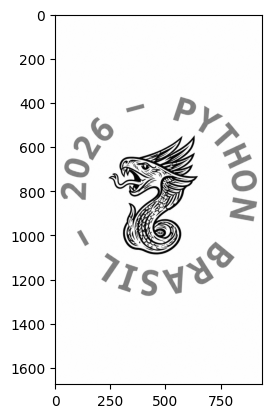

In [28]:
logo = cv2.imread("logo_python_brasil.png")
logo = cv2.cvtColor(logo, cv2.COLOR_BGR2RGB)

logo_grayscale = np.mean(logo, axis = 2)

plt.imshow(logo_grayscale, cmap = "gray")
plt.show()

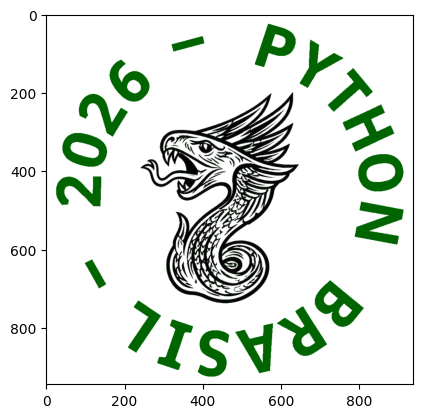

In [85]:
new_logo = logo.copy()

threshold = 220
# Set all clear pixels to be exactly white
new_logo[logo_grayscale >= threshold, :] = 255

# Get all pixels that are green in the image
# We assume the color is green as long as the green component is higher than the red and blue (not exactly green, but works here)
green_pixels = (new_logo[:,:,1] > (new_logo[:,:,0])) & (new_logo[:,:,1] > (new_logo[:,:,2])) & (logo_grayscale[:,:] > 100)

# Set all green pixels to be exactly green
# new_logo[green_pixels, 0] = 173
# new_logo[green_pixels, 1] = 255
# new_logo[green_pixels, 2] = 47
new_logo[green_pixels, 0] = 0
new_logo[green_pixels, 1] = 100
new_logo[green_pixels, 2] = 0

# Crop image as a square
new_logo = new_logo[350:-380,:,:]

plt.imshow(new_logo, cmap = "gray")
plt.show()

In [86]:
# Convert image to support alpha values
logo_rgba = cv2.cvtColor(new_logo, cv2.COLOR_RGB2RGBA)

# Take all white pixels from the background
white_pixels = np.all(new_logo == [255, 255, 255], axis=2)

logo_rgba[white_pixels, 3] = 0

logo_bgra = cv2.cvtColor(logo_rgba, cv2.COLOR_RGBA2BGRA)

cv2.imwrite("new_logo.png", logo_bgra)

True